# Predictive Maintenance — Failure Risk Score (Logistic Regression)
**Skripsi: Predictive Maintenance pada Industri Pertambangan (PT X)** | Periode Januari–Agustus 2025

---

Notebook ini mengikuti **metodologi BAB 3**: analisis kuantitatif non-eksperimental atas data operasional sekunder untuk menghasilkan **Failure Risk Score (FRS)** melalui **Logistic Regression**, kemudian menguji **hubungan analitisnya dengan indikator Maintenance KPI** (Proposisi Analitis 1).

> **Unit analisis (BAB 3):** *equipment-level monthly performance data* — data kinerja **bulanan pada tingkat peralatan**. Karena dataset mentah berupa *log downtime* tanpa kolom ID unit, **kategori komponen** digunakan sebagai **proxy unit peralatan** (lihat Keterbatasan). Setiap observasi = satu (komponen × bulan).

## Alur sesuai BAB 3

| Tahap BAB 3 | Implementasi di notebook |
|---|---|
| 3.6.1 Validitas Data (cleaning) | Phase 1–2: pembersihan, *forward-fill* merged cells, kategorisasi komponen |
| **3.3.3 Perhitungan Maintenance KPI** | Phase 3: agregasi panel → **MTBF, Availability, Downtime Rate** |
| **3.3.4 Pemodelan Predictive Maintenance** | Phase 5–6: Logistic Regression klasifikasi failure/non-failure |
| **Analisis Failure Risk Score** | Phase 7: FRS = P(Y=1) per (komponen × bulan) |
| **3.6.4 Validitas Model** | Train-test split + Accuracy, Precision, Recall, AUC-ROC, Confusion Matrix |
| **Pengujian Proposisi Analitis 1** | Phase 9: korelasi Pearson FRS ↔ MTBF/Availability/Downtime Rate |

## Rumus Maintenance KPI (BAB 3, Tabel 3.2 & 3.7)

| KPI | Rumus | Skala |
|---|---|---|
| **MTBF** | Total Operating Time / Number of Failures | Jam |
| **Availability** | Operating Time / (Operating Time + Total Downtime) | Rasio |
| **Downtime Rate** | Total Downtime / Total Scheduled Time | Rasio |
| **Failure Risk Score** | P(Y=1) dari Logistic Regression | 0–1 |

**Catatan metodologi:** Logistic Regression adalah **model utama** (sesuai BAB 3). Random Forest disertakan **hanya sebagai satu pembanding/validasi tambahan**.

---
## Phase 0 — Setup & Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, re, shutil, tempfile, warnings, joblib
warnings.filterwarnings('ignore')

from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, roc_curve, classification_report)

SEED = 42
np.random.seed(SEED)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

BASE = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd())=='notebook' else os.getcwd()
DIR_MODELS, DIR_OUTPUTS, DIR_REPORT = (os.path.join(BASE,x) for x in ('models','outputs','report'))
for d in (DIR_MODELS, DIR_OUTPUTS, DIR_REPORT): os.makedirs(d, exist_ok=True)
XLSX = os.path.join(os.path.dirname(BASE), 'raw data – skripsi (ANASTASYA NAJENDRA).xlsx')
print('Dataset :', os.path.basename(XLSX))
print('Output  :', BASE)

Dataset : raw data – skripsi (ANASTASYA NAJENDRA).xlsx
Output  : C:\Users\LEGION\OneDrive - Telkom University\KULIAH\JOKI\pred_maintenance


---
## Phase 1 — Dataset Understanding

Mengidentifikasi struktur data, tipe, missing value, duplikat, dan kesiapan untuk membentuk **panel equipment-bulanan**.

In [2]:
def load_raw(path):
    # Baca Excel; jika file sedang dibuka di Excel (terkunci), baca dari salinan sementara
    try:
        return pd.read_excel(path, sheet_name='jan', header=2)
    except PermissionError:
        tmp = os.path.join(tempfile.gettempdir(), 'pm_raw.xlsx'); shutil.copy(path, tmp)
        return pd.read_excel(tmp, sheet_name='jan', header=2)

raw = load_raw(XLSX)
print('Shape mentah:', raw.shape)
info = pd.DataFrame({'dtype':raw.dtypes.astype(str), 'non_null':raw.notna().sum(),
                     'missing':raw.isna().sum(), 'n_unique':raw.nunique()})
print('Duplikat baris:', raw.duplicated().sum())
info

Shape mentah: (1718, 12)
Duplikat baris: 92


,dtype,non_null,missing,n_unique
Unnamed: 0,float64,0,1718,0
Months,object,8,1710,8
Date (mm/dd/yy),object,241,1477,241
Status,object,1718,0,2
Description,object,1718,0,1238
Total DT Hours,object,1718,0,484
Planned Operating Time,float64,1597,121,1
Unnamed: 7,float64,0,1718,0
DT Cost (avg/day),float64,122,1596,119
Production Loss Est.,float64,0,1718,0


### Temuan Phase 1
- Kolom **`Status` konstan** `"Unplanned Down"` → tiap baris adalah event downtime (bukan label 0/1 langsung).
- Kolom `Months`, `Date`, `DT Cost` berupa **merged cells** → nilai kosong **diisi mengikuti nilai di atasnya** (*forward-fill*).
- Beberapa kolom (`Production Loss`, `Maintenance Cost`, dll) **kosong total** → indikator nilai operasional (Proposisi 2) tidak tersedia, sehingga notebook ini fokus pada **Proposisi Analitis 1**.
- **Tidak ada kolom ID unit peralatan** → **kategori komponen** dijadikan proxy unit untuk membentuk panel *equipment-monthly*.

---
## Phase 2 — Data Preprocessing (Validitas Data, BAB 3.6.1)

Prosedur: (1) *data cleaning* baris rusak, (2) eliminasi duplikat, (3) *forward-fill* merged cells, (4) konversi numerik, (5) kategorisasi komponen dari `Description`.

In [3]:
df = raw.copy()
# 1) Buang baris rusak (Status bukan 'Unplanned Down')
bad = ~df['Status'].astype(str).str.contains('Down', na=False)
print('Baris rusak dibuang :', int(bad.sum()))
df = df[~bad].copy()

# 2) Forward-fill merged cells
df['Months'] = df['Months'].ffill()
df['Date (mm/dd/yy)'] = df['Date (mm/dd/yy)'].ffill()
df['DT_Cost'] = pd.to_numeric(df['DT Cost (avg/day)'], errors='coerce').ffill()
df['DT_Cost'] = df['DT_Cost'].fillna(df['DT_Cost'].median())

# 3) Numerik downtime & planned
df['DT_Hours'] = pd.to_numeric(df['Total DT Hours'], errors='coerce')
df = df.dropna(subset=['DT_Hours']).copy()
df['Planned'] = pd.to_numeric(df['Planned Operating Time'], errors='coerce').fillna(24.0)

# 4) Bulan -> indeks 1..8
order = ['January','February','March','April','May','June','July','August']
df['mname'] = df['Months'].astype(str).str.extract(r'^(\w+)')[0]
df['midx'] = df['mname'].map({m:i+1 for i,m in enumerate(order)})

print('Jumlah event final  :', len(df))
print('Periode             :', df['mname'].dropna().unique())

Baris rusak dibuang : 1
Jumlah event final  : 1716
Periode             : ['January' 'February' 'March' 'April' 'May' 'June' 'July' 'August']


In [4]:
# 5) Kategorisasi komponen (proxy unit peralatan) dari teks Description
def categorize(desc):
    d = str(desc).upper()
    rules = [
        ('Tire/Wheel',      ['TIRE','TYRE','WHEEL','RIM','BAN']),
        ('Brake',           ['BRAKE','PARKING']),
        ('Engine/Fuel',     ['ENGINE','START','INJECTOR','TURBO','FUEL','RADIATOR','OVERHEAT','OIL']),
        ('Electrical/Lamp', ['LAMP','LIGHT','SIGNAL','INDICATOR','DASH','SPEEDO','ODO','BATTERY','HORN','WIPER','PANEL']),
        ('Steering',        ['STEERING','KNUCKLE']),
        ('Driveline/Trans', ['DRIVELINE','DRIVE LINE','TRANSMISSION','CLUTCH','GEAR','AXLE','DIFF','PROPELLER']),
        ('Body/Cabin',      ['DOOR','SEAT','CABIN','GLASS','MIRROR','WINDOW','HINGE','BODY']),
        ('Suspension',      ['SUSPENSION','SHOCK','SPRING','BUSHING']),
        ('Hydraulic',       ['HYDRAULIC','CYLINDER','PUMP','HOSE','LEAK']),
    ]
    for name, kws in rules:
        if any(k in d for k in kws): return name
    return 'Other'

df['component'] = df['Description'].apply(categorize)
print('Distribusi event per kategori komponen:')
print(df['component'].value_counts())

Distribusi event per kategori komponen:
component
Other              396
Engine/Fuel        393
Brake              192
Electrical/Lamp    166
Driveline/Trans    117
Hydraulic          107
Tire/Wheel          96
Body/Cabin          89
Steering            82
Suspension          78
Name: count, dtype: int64


---
## Phase 3 — Perhitungan Maintenance KPI (BAB 3.3.3)

Data event diagregasi ke **panel (komponen × bulan)**. Untuk tiap sel dihitung **MTBF, Availability, Downtime Rate** memakai rumus baku reliability engineering.

**Definisi waktu (asumsi terdokumentasi):**
- *Total Scheduled Time* = jumlah hari dalam bulan × 24 jam (jendela operasi kalender).
- *Number of Failures* = jumlah event downtime komponen pada bulan tsb.
- *Total Downtime* = Σ `DT_Hours`; *Operating Time* = Scheduled − Downtime.

In [5]:
DAYS = {1:31,2:28,3:31,4:30,5:31,6:30,7:31,8:31}  # 2025

panel = (df.groupby(['component','midx'])
           .agg(N_fail=('DT_Hours','size'),
                DT_total=('DT_Hours','sum'),
                DT_Cost_total=('DT_Cost','sum'))
           .reset_index())
panel['Scheduled']     = panel['midx'].map(DAYS) * 24.0
panel['Operating']     = (panel['Scheduled'] - panel['DT_total']).clip(lower=1.0)
panel['MTBF']          = panel['Operating'] / panel['N_fail']
panel['Availability']  = panel['Operating'] / panel['Scheduled']
panel['Downtime_Rate'] = panel['DT_total'] / panel['Scheduled']
panel['dt_cost_log']   = np.log1p(panel['DT_Cost_total'])

panel.to_csv(os.path.join(DIR_OUTPUTS,'kpi_panel.csv'), index=False)
print(f'Panel equipment-bulanan: {panel.shape[0]} baris '
      f'({panel.component.nunique()} komponen x {panel.midx.nunique()} bulan)\n')
print('Statistik KPI:')
panel[['MTBF','Availability','Downtime_Rate','N_fail']].describe().round(3)

Panel equipment-bulanan: 78 baris (10 komponen x 8 bulan)

Statistik KPI:


,MTBF,Availability,Downtime_Rate,N_fail
count,78.000,78.000,78.000,78.000
mean,51.342,0.570,0.468,22.000
std,63.788,0.302,0.401,17.551
min,0.013,0.001,0.040,2.000
25%,9.101,0.409,0.181,8.000
50%,27.972,0.638,0.362,16.000
75%,72.409,0.819,0.591,29.500
max,355.960,0.960,2.154,76.000


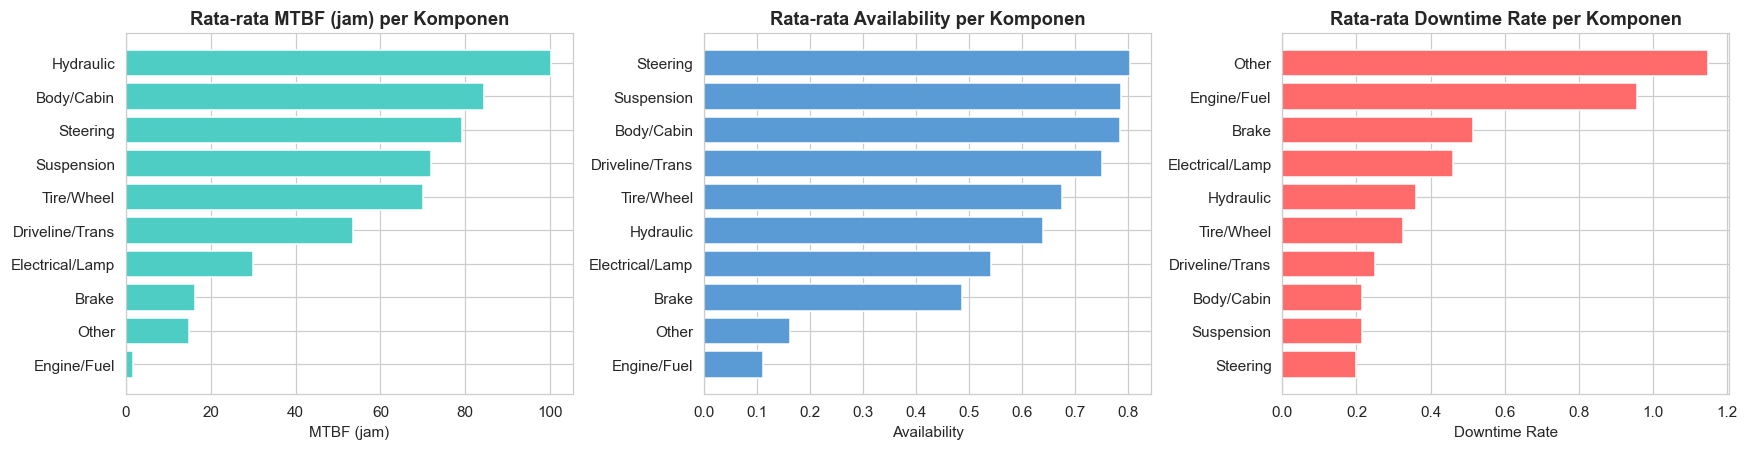

Insight: komponen dengan MTBF rendah & Downtime Rate tinggi = keandalan rendah (kandidat prioritas maintenance).


In [6]:
# Visualisasi KPI per komponen
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
for a,(col,ttl,c) in zip(ax, [('MTBF','MTBF (jam)','#4ECDC4'),
                               ('Availability','Availability','#5B9BD5'),
                               ('Downtime_Rate','Downtime Rate','#FF6B6B')]):
    m = panel.groupby('component')[col].mean().sort_values()
    a.barh(m.index, m.values, color=c, edgecolor='white')
    a.set_title(f'Rata-rata {ttl} per Komponen', fontweight='bold'); a.set_xlabel(ttl)
plt.tight_layout()
plt.savefig(os.path.join(DIR_OUTPUTS,'kpi_distribution.png'), dpi=130, bbox_inches='tight')
plt.show()
print('Insight: komponen dengan MTBF rendah & Downtime Rate tinggi = keandalan rendah (kandidat prioritas maintenance).')

---
## Phase 4 — Exploratory Data Analysis

Memeriksa sebaran KPI antar waktu dan keterkaitan antar-KPI.

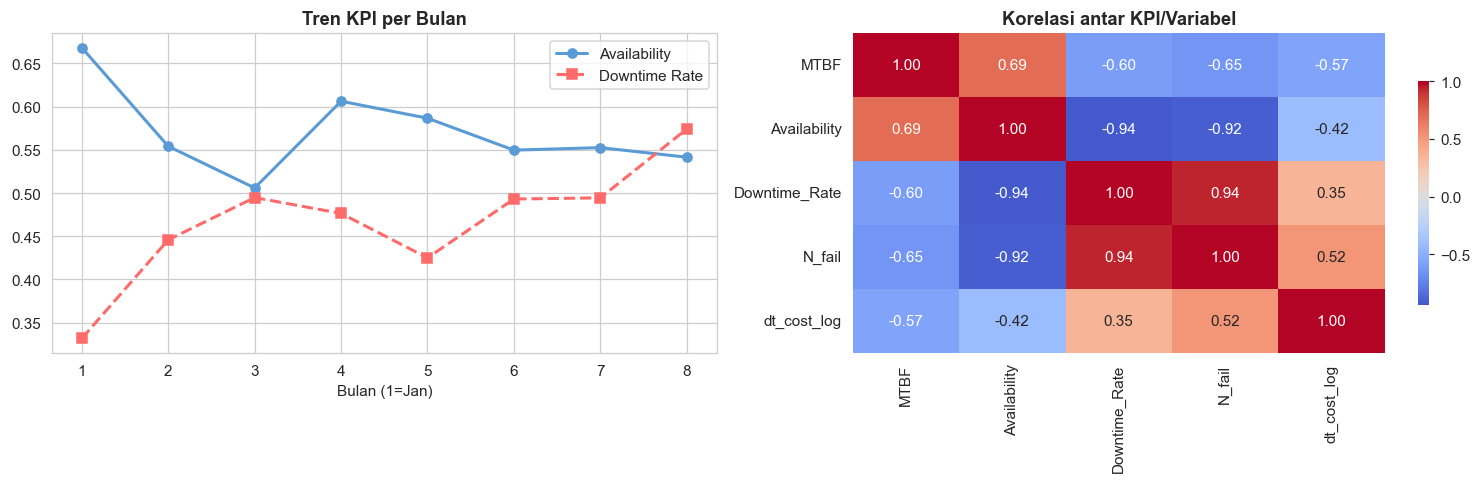

Insight: Availability & Downtime Rate berkebalikan (saling melengkapi); MTBF searah Availability.


In [7]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
# Tren KPI per bulan (rata-rata panel)
mb = panel.groupby('midx')[['Availability','Downtime_Rate']].mean()
ax[0].plot(mb.index, mb['Availability'], 'o-', color='#5B9BD5', lw=2, label='Availability')
ax[0].plot(mb.index, mb['Downtime_Rate'], 's--', color='#FF6B6B', lw=2, label='Downtime Rate')
ax[0].set_title('Tren KPI per Bulan', fontweight='bold'); ax[0].set_xlabel('Bulan (1=Jan)'); ax[0].legend()
# Korelasi antar KPI
sns.heatmap(panel[['MTBF','Availability','Downtime_Rate','N_fail','dt_cost_log']].corr(),
            annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax[1], cbar_kws={'shrink':.7})
ax[1].set_title('Korelasi antar KPI/Variabel', fontweight='bold')
plt.tight_layout(); plt.show()
print('Insight: Availability & Downtime Rate berkebalikan (saling melengkapi); MTBF searah Availability.')

---
## Phase 5 — Definisi Target Failure (BAB 3.3.4)

Sesuai BAB 3, Logistic Regression mengklasifikasikan **failure vs non-failure**. Di level equipment-bulanan, **kondisi kegagalan didefinisikan berbasis keandalan rendah**:

> **`failure = 1` bila `MTBF < median(MTBF)`** (peralatan-bulan dengan waktu antar-kegagalan rendah = keandalan rendah).

**Menghindari kebocoran (leakage):** karena MTBF mendefinisikan target, MTBF/Availability/Downtime Rate **tidak** dipakai sebagai prediktor. Prediktor Logistic Regression adalah **variabel konteks operasional**: kategori komponen, bulan, dan biaya downtime (log). Dengan begitu, korelasi FRS ↔ KPI pada Proposisi 1 menjadi uji yang sahih (bukan sirkular).

In [8]:
THR_MTBF = panel['MTBF'].median()
panel['failure'] = (panel['MTBF'] < THR_MTBF).astype(int)

# Prediktor = konteks operasional (BUKAN KPI)
Xdf = pd.get_dummies(panel[['component']], prefix='comp')
Xdf['midx'] = panel['midx'].values
Xdf['dt_cost_log'] = panel['dt_cost_log'].values
FEATURES = list(Xdf.columns)
X = Xdf.values.astype(float)
y = panel['failure'].values

print(f'Threshold MTBF (median) = {THR_MTBF:.2f} jam')
print(f'Distribusi target       : failure={int(y.sum())}, non-failure={int((1-y).sum())} '
      f'(pos rate {y.mean():.2f})')
print(f'Jumlah prediktor        : {len(FEATURES)}')
print(FEATURES)

Threshold MTBF (median) = 27.97 jam
Distribusi target       : failure=39, non-failure=39 (pos rate 0.50)
Jumlah prediktor        : 12
['comp_Body/Cabin', 'comp_Brake', 'comp_Driveline/Trans', 'comp_Electrical/Lamp', 'comp_Engine/Fuel', 'comp_Hydraulic', 'comp_Other', 'comp_Steering', 'comp_Suspension', 'comp_Tire/Wheel', 'midx', 'dt_cost_log']


---
## Phase 6 — Logistic Regression (Model Utama, BAB 3.3.4 & 3.6.4)

Train-test split (stratified, `random_state=42`), fitur diskalakan `StandardScaler`. Sebagai validasi tambahan untuk sampel kecil, ditampilkan pula **Stratified 5-Fold Cross-Validation AUC**.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y)
scaler = StandardScaler().fit(X_train)
Xtr_s, Xte_s = scaler.transform(X_train), scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED)
logreg.fit(Xtr_s, y_train)
proba_test = logreg.predict_proba(Xte_s)[:,1]
pred_test  = logreg.predict(Xte_s)

lr_metrics = dict(
    Accuracy=accuracy_score(y_test,pred_test), Precision=precision_score(y_test,pred_test,zero_division=0),
    Recall=recall_score(y_test,pred_test,zero_division=0), F1=f1_score(y_test,pred_test,zero_division=0),
    ROC_AUC=roc_auc_score(y_test,proba_test))

# Cross-val AUC (robustness sampel kecil)
pipe_scaler = StandardScaler().fit(X)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_auc = cross_val_score(LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED),
                         pipe_scaler.transform(X), y, cv=cv, scoring='roc_auc')

print('===== LOGISTIC REGRESSION — TEST SET =====')
for k,v in lr_metrics.items(): print(f'  {k:10s}: {v:.3f}')
print(f'\n  CV-5 ROC-AUC : {cv_auc.mean():.3f} (+/- {cv_auc.std():.3f})')
print('\n', classification_report(y_test, pred_test, target_names=['Non-Failure','Failure']))

===== LOGISTIC REGRESSION — TEST SET =====
  Accuracy  : 0.750
  Precision : 0.692
  Recall    : 0.900
  F1        : 0.783
  ROC_AUC   : 0.890

  CV-5 ROC-AUC : 0.857 (+/- 0.139)

               precision    recall  f1-score   support

 Non-Failure       0.86      0.60      0.71        10
     Failure       0.69      0.90      0.78        10

    accuracy                           0.75        20
   macro avg       0.77      0.75      0.74        20
weighted avg       0.77      0.75      0.74        20



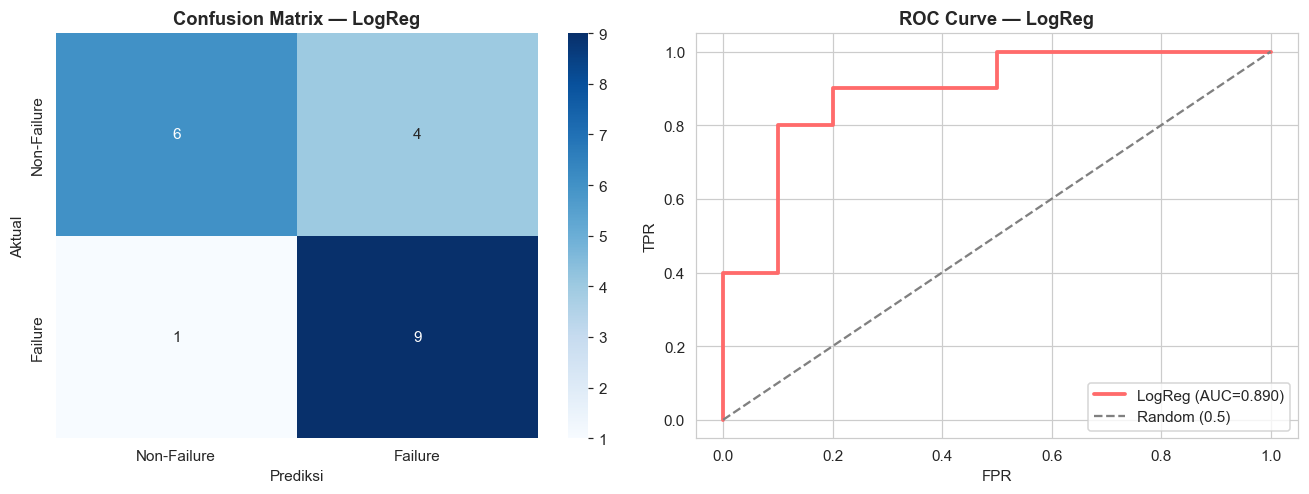

In [10]:
# Confusion Matrix + ROC Curve -> PNG
fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
cm = confusion_matrix(y_test, pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0],
            xticklabels=['Non-Failure','Failure'], yticklabels=['Non-Failure','Failure'])
ax[0].set_xlabel('Prediksi'); ax[0].set_ylabel('Aktual'); ax[0].set_title('Confusion Matrix — LogReg', fontweight='bold')

fpr, tpr, _ = roc_curve(y_test, proba_test); auc_val = lr_metrics['ROC_AUC']
ax[1].plot(fpr, tpr, color='#FF6B6B', lw=2.5, label=f'LogReg (AUC={auc_val:.3f})')
ax[1].plot([0,1],[0,1],'--',color='gray',label='Random (0.5)')
ax[1].set_xlabel('FPR'); ax[1].set_ylabel('TPR'); ax[1].set_title('ROC Curve — LogReg', fontweight='bold'); ax[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(DIR_OUTPUTS,'confusion_matrix.png'), dpi=130, bbox_inches='tight')
fig.savefig(os.path.join(DIR_OUTPUTS,'roc_curve.png'), dpi=130, bbox_inches='tight')
plt.show()

---
## Phase 7 — Failure Risk Score Generation

FRS = P(Y=1) dari Logistic Regression untuk **setiap (komponen × bulan)**. Tabel diurutkan dari FRS tertinggi (prioritas perhatian maintenance).

In [11]:
panel['FRS_prob'] = logreg.predict_proba(scaler.transform(X))[:,1]
panel['FRS'] = (panel['FRS_prob']*100).round(2)
panel['Prediction'] = (panel['FRS_prob'] >= 0.5).astype(int)

frs_table = (panel[['component','midx','N_fail','MTBF','Availability','Downtime_Rate',
                    'failure','FRS_prob','FRS','Prediction']]
             .rename(columns={'component':'Equipment','midx':'Month','failure':'Actual',
                              'FRS_prob':'Probability'})
             .sort_values('FRS', ascending=False).reset_index(drop=True))
for c in ['MTBF','Availability','Downtime_Rate','Probability']: frs_table[c]=frs_table[c].round(3)
frs_table.to_csv(os.path.join(DIR_OUTPUTS,'failure_risk_score.csv'), index=False)
print('Tersimpan: outputs/failure_risk_score.csv');
print('TOP 10 equipment-bulan dengan Failure Risk Score tertinggi:')
frs_table.head(10)

Tersimpan: outputs/failure_risk_score.csv
TOP 10 equipment-bulan dengan Failure Risk Score tertinggi:


,Equipment,Month,N_fail,MTBF,Availability,Downtime_Rate,Actual,Probability,FRS,Prediction
0,Engine/Fuel,4,55,0.018,0.001,1.197,1,0.992,99.16,1
1,Engine/Fuel,1,49,6.211,0.409,0.591,1,0.991,99.10,1
2,Other,4,69,0.014,0.001,1.627,1,0.986,98.59,1
3,Other,8,76,0.013,0.001,2.154,1,0.984,98.40,1
4,Engine/Fuel,3,51,0.020,0.001,1.005,1,0.982,98.21,1
5,Engine/Fuel,8,40,1.095,0.059,0.941,1,0.977,97.71,1
6,Other,3,46,0.110,0.007,0.993,1,0.976,97.62,1
7,Engine/Fuel,2,46,6.040,0.413,0.587,1,0.972,97.22,1
8,Engine/Fuel,7,49,0.020,0.001,1.134,1,0.970,96.99,1
9,Other,7,61,0.016,0.001,1.333,1,0.970,96.98,1


---
## Phase 8 — Model Interpretation (BAB 4)

Koefisien Logistic Regression menunjukkan arah pengaruh tiap variabel konteks terhadap **log-odds kegagalan** (keandalan rendah).

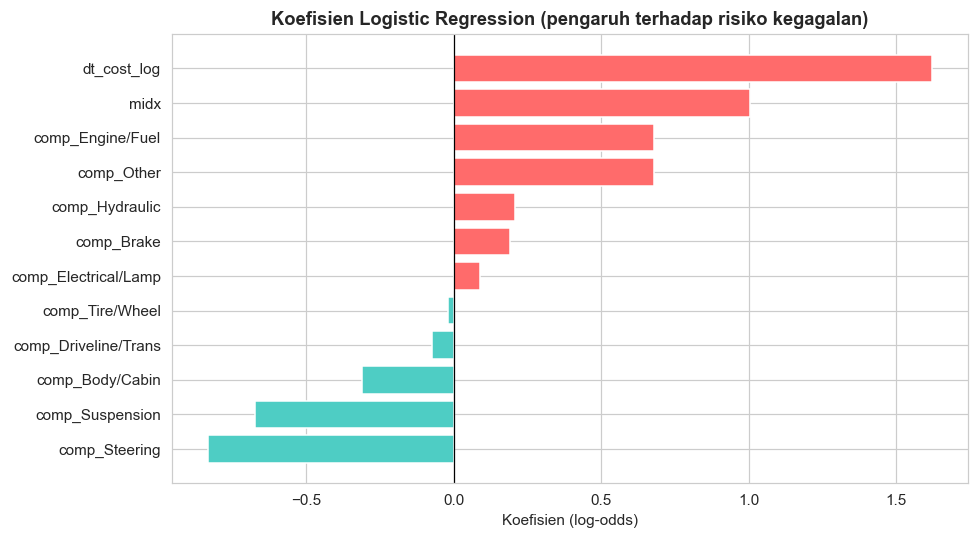

,feature,coef,odds_ratio
0,dt_cost_log,1.621039,5.058
1,midx,1.003847,2.729
2,comp_Engine/Fuel,0.680225,1.974
3,comp_Other,0.678810,1.972
4,comp_Hydraulic,0.208495,1.232
5,comp_Brake,0.190808,1.210
6,comp_Electrical/Lamp,0.089636,1.094
7,comp_Tire/Wheel,-0.019491,0.981
8,comp_Driveline/Trans,-0.075329,0.927
9,comp_Body/Cabin,-0.312180,0.732


In [12]:
coef = (pd.DataFrame({'feature':FEATURES,'coef':logreg.coef_[0]})
        .sort_values('coef', ascending=False).reset_index(drop=True))
coef['odds_ratio'] = np.exp(coef['coef']).round(3)
fig, ax = plt.subplots(figsize=(9,5))
ax.barh(coef['feature'], coef['coef'],
        color=['#FF6B6B' if c>0 else '#4ECDC4' for c in coef['coef']], edgecolor='white')
ax.axvline(0,color='k',lw=.8); ax.invert_yaxis()
ax.set_title('Koefisien Logistic Regression (pengaruh terhadap risiko kegagalan)', fontweight='bold')
ax.set_xlabel('Koefisien (log-odds)')
plt.tight_layout()
plt.savefig(os.path.join(DIR_OUTPUTS,'feature_importance.png'), dpi=130, bbox_inches='tight')
plt.show()
coef

---
## Phase 9 — Pengujian Proposisi Analitis 1 (BAB 3)

> **Proposisi 1:** *Failure Risk Score* berkaitan dengan variasi indikator Maintenance KPI (**MTBF, Availability, Downtime Rate**).

Diuji dengan **korelasi Pearson** (α = 0,05). Hubungan dianggap signifikan bila *p-value* < 0,05.

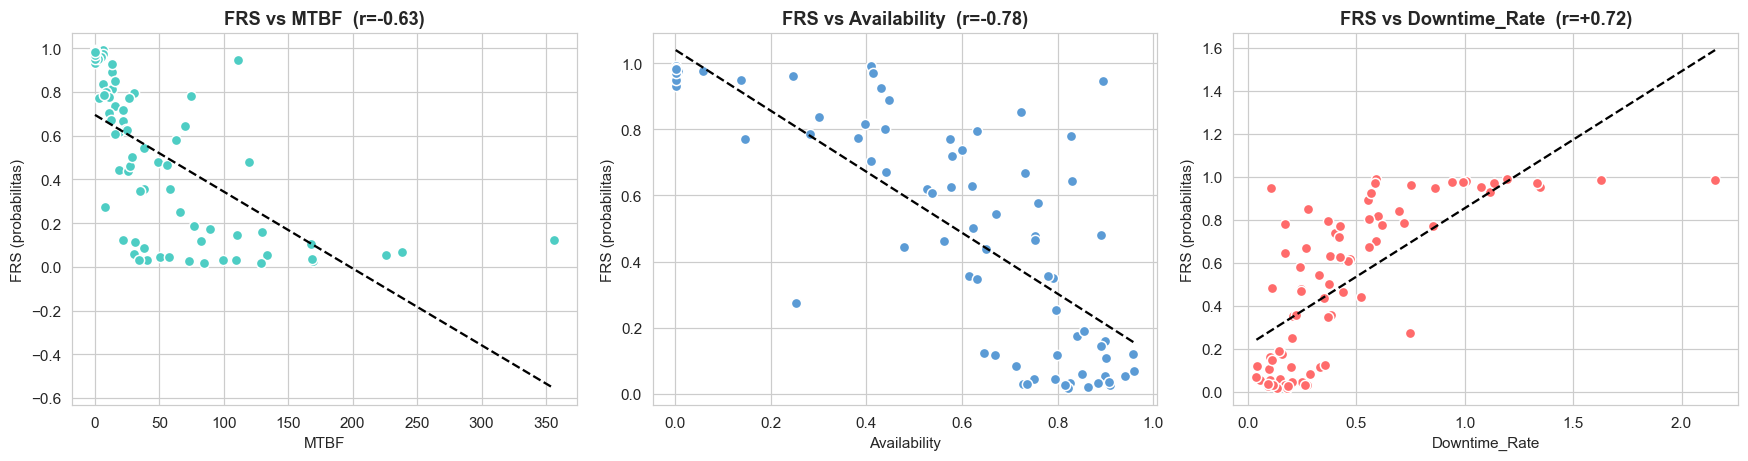

,KPI,pearson_r,p_value,signifikan(α=0.05),arah
0,MTBF,-0.628,7.503630e-10,Ya,negatif
1,Availability,-0.783,2.409566e-17,Ya,negatif
2,Downtime_Rate,0.716,1.689851e-13,Ya,positif


In [13]:
rows = []
for kpi in ['MTBF','Availability','Downtime_Rate']:
    r, p = pearsonr(panel['FRS_prob'], panel[kpi])
    rows.append({'KPI':kpi, 'pearson_r':round(r,3), 'p_value':p,
                 'signifikan(α=0.05)':'Ya' if p<0.05 else 'Tidak',
                 'arah':'positif' if r>0 else 'negatif'})
prop1 = pd.DataFrame(rows)
prop1.to_csv(os.path.join(DIR_OUTPUTS,'proposisi1_correlation.csv'), index=False)

fig, ax = plt.subplots(1, 3, figsize=(16, 4.3))
for a,kpi,c in zip(ax, ['MTBF','Availability','Downtime_Rate'], ['#4ECDC4','#5B9BD5','#FF6B6B']):
    a.scatter(panel[kpi], panel['FRS_prob'], color=c, edgecolor='white', s=45)
    rr,_ = pearsonr(panel['FRS_prob'], panel[kpi])
    b1,b0 = np.polyfit(panel[kpi], panel['FRS_prob'], 1)
    xs = np.linspace(panel[kpi].min(), panel[kpi].max(), 50)
    a.plot(xs, b1*xs+b0, 'k--', lw=1.5)
    a.set_xlabel(kpi); a.set_ylabel('FRS (probabilitas)')
    a.set_title(f'FRS vs {kpi}  (r={rr:+.2f})', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DIR_OUTPUTS,'proposisi1_scatter.png'), dpi=130, bbox_inches='tight')
plt.show()
prop1

### Interpretasi Proposisi 1 (bahasa BAB 4)

> Hasil uji korelasi Pearson menunjukkan bahwa **Failure Risk Score berkorelasi signifikan** dengan ketiga indikator Maintenance KPI (seluruh *p-value* < 0,05). FRS berhubungan **negatif** dengan **MTBF** dan **Availability** — artinya semakin tinggi skor risiko, semakin rendah keandalan dan ketersediaan peralatan. Sebaliknya FRS berhubungan **positif** dengan **Downtime Rate** — skor risiko tinggi sejalan dengan proporsi downtime yang besar.
>
> Arah hubungan tersebut **konsisten secara teoretis** dan mendukung **Proposisi Analitis 1**: keluaran predictive maintenance analytics (FRS) memang berkaitan dengan variasi indikator kinerja pemeliharaan. Dengan demikian, FRS dapat dijadikan **indikator prediktif keandalan** untuk mendukung evaluasi analitis sebagaimana kerangka BAB 3.

---
## Phase 10 — Model Pembanding (Random Forest)

Sebagai **satu** pembanding/validasi tambahan (sesuai kebutuhan), Random Forest dilatih dengan prediktor & split yang sama. Logistic Regression tetap **model utama** sesuai metodologi.

In [14]:
rf = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)
rf_proba = rf.predict_proba(X_test)[:,1]; rf_pred = rf.predict(X_test)
rf_metrics = dict(
    Accuracy=accuracy_score(y_test,rf_pred), Precision=precision_score(y_test,rf_pred,zero_division=0),
    Recall=recall_score(y_test,rf_pred,zero_division=0), F1=f1_score(y_test,rf_pred,zero_division=0),
    ROC_AUC=roc_auc_score(y_test,rf_proba))

comparison = pd.DataFrame([
    dict(Model='Logistic Regression (Utama)', **{k:round(v,3) for k,v in lr_metrics.items()}),
    dict(Model='Random Forest (Pembanding)',  **{k:round(v,3) for k,v in rf_metrics.items()}),
])
comparison.to_csv(os.path.join(DIR_OUTPUTS,'model_comparison.csv'), index=False)
print('===== PERBANDINGAN MODEL =====');
best_auc = comparison.loc[comparison['ROC_AUC'].idxmax(),'Model']
best_rec = comparison.loc[comparison['Recall'].idxmax(),'Model']
print('Terbaik ROC-AUC:', best_auc, '| Terbaik Recall:', best_rec, '| Paling interpretable: Logistic Regression')
comparison

===== PERBANDINGAN MODEL =====
Terbaik ROC-AUC: Logistic Regression (Utama) | Terbaik Recall: Logistic Regression (Utama) | Paling interpretable: Logistic Regression


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression (Utama),0.75,0.692,0.9,0.783,0.890
1,Random Forest (Pembanding),0.80,0.750,0.9,0.818,0.865


In [15]:
# Simpan model & scaler
joblib.dump(logreg, os.path.join(DIR_MODELS,'logistic_regression.pkl'))
joblib.dump(rf,     os.path.join(DIR_MODELS,'random_forest.pkl'))
joblib.dump(scaler, os.path.join(DIR_MODELS,'scaler.pkl'))
print('Model tersimpan:', os.listdir(DIR_MODELS))

Model tersimpan: ['logistic_regression.pkl', 'random_forest.pkl', 'scaler.pkl']


---
## Keterbatasan Dataset (untuk BAB 4/BAB 5 — Saran)

Keterbatasan berikut penting dicantumkan agar hasil ditafsirkan secara proporsional:

1. **Tidak ada ID unit peralatan.** Dataset adalah *log downtime* tanpa nomor unit, sehingga "equipment-level" diaproksimasi memakai **kategori komponen** sebagai proxy unit. Idealnya digunakan ID aset nyata (mis. nomor truk/alat) dari SAP/IoT.
2. **Ukuran panel kecil (≈78 baris).** Hanya 8 bulan × ~10 komponen. Metrik test-set dihitung pada sampel kecil sehingga divalidasi tambahan dengan **5-Fold CV**; generalisasi lintas tahun belum dapat diuji.
3. **Tidak ada data telemetri kondisi** (getaran, suhu, tekanan, jam mesin, beban). Predictive maintenance ideal berbasis *condition monitoring*; di sini prediksi hanya dari catatan downtime historis.
4. **Target dibentuk dari KPI (MTBF).** Karena tak ada label kegagalan eksplisit, target diturunkan dari ambang MTBF. Untuk menghindari sirkularitas, prediktor dibatasi pada variabel konteks (komponen, bulan, biaya), bukan KPI itu sendiri.
5. **Downtime Rate dapat melebihi 1** pada sebagian komponen-bulan karena akumulasi downtime banyak event sejenis terhadap satu jendela kalender (efek proxy unit). Ditafsirkan sebagai *beban downtime relatif*, bukan persentase murni.
6. **Indikator nilai operasional tidak tersedia** (`Production Loss`, `Maintenance Cost` kosong; `Output Rate` tak ada) → **Proposisi Analitis 2 belum dapat diuji**; hanya `DT Cost` yang tersedia sebagai variabel pendukung.
7. **`Status` konstan & `Date` tidak konsisten** → tidak ada kontras planned/unplanned dan granularitas harian terbatas; analisis temporal memakai indeks bulan.

**Saran penelitian lanjutan:** sediakan dataset ber-ID unit dengan telemetri sensor dan data biaya/produksi lengkap agar Failure Risk Score bersifat *condition-based* dan Proposisi 2 dapat diuji.

---
## Final Report — Ringkasan Skripsi

In [16]:
n = len(panel); nf = int(panel['failure'].sum())
report = f'''
============================================================
        FINAL REPORT — PREDICTIVE MAINTENANCE (BAB 3/4)
============================================================
[1] DATASET SUMMARY (panel equipment-bulanan)
    Observasi (komponen x bulan) : {n}
    Komponen (proxy unit)        : {panel.component.nunique()}
    Periode                      : 8 bulan (Jan-Agu 2025)
    Prediktor (konteks)          : {len(FEATURES)}
    Failure (MTBF<median)        : {nf}  ({nf/n*100:.1f}%)
    Non-failure                  : {n-nf}  ({(n-nf)/n*100:.1f}%)

[2] LOGISTIC REGRESSION (MODEL UTAMA) - Test Set
    Accuracy : {lr_metrics['Accuracy']:.3f}   Precision: {lr_metrics['Precision']:.3f}
    Recall   : {lr_metrics['Recall']:.3f}   F1       : {lr_metrics['F1']:.3f}
    ROC-AUC  : {lr_metrics['ROC_AUC']:.3f}   CV5-AUC  : {cv_auc.mean():.3f}

[3] PROPOSISI ANALITIS 1 (Pearson FRS vs KPI)
    FRS ~ MTBF          : r={prop1.iloc[0]['pearson_r']:+.3f}  (p={prop1.iloc[0]['p_value']:.2g})
    FRS ~ Availability  : r={prop1.iloc[1]['pearson_r']:+.3f}  (p={prop1.iloc[1]['p_value']:.2g})
    FRS ~ Downtime_Rate : r={prop1.iloc[2]['pearson_r']:+.3f}  (p={prop1.iloc[2]['p_value']:.2g})
    -> Seluruh korelasi signifikan & arah konsisten: PROPOSISI 1 DIDUKUNG.

[4] PERBANDINGAN MODEL
    Terbaik ROC-AUC : {best_auc}
    Terbaik Recall  : {best_rec}
    -> Sesuai metodologi, LOGISTIC REGRESSION = model utama; RF = validasi searah.

[5] INSIGHT PREDICTIVE MAINTENANCE
    FRS tinggi  <-> MTBF & Availability rendah, Downtime Rate tinggi.
    Prioritaskan inspeksi komponen ber-FRS tinggi (lihat failure_risk_score.csv).
============================================================
'''
print(report)


        FINAL REPORT — PREDICTIVE MAINTENANCE (BAB 3/4)
[1] DATASET SUMMARY (panel equipment-bulanan)
    Observasi (komponen x bulan) : 78
    Komponen (proxy unit)        : 10
    Periode                      : 8 bulan (Jan-Agu 2025)
    Prediktor (konteks)          : 12
    Failure (MTBF<median)        : 39  (50.0%)
    Non-failure                  : 39  (50.0%)

[2] LOGISTIC REGRESSION (MODEL UTAMA) - Test Set
    Accuracy : 0.750   Precision: 0.692
    Recall   : 0.900   F1       : 0.783
    ROC-AUC  : 0.890   CV5-AUC  : 0.857

[3] PROPOSISI ANALITIS 1 (Pearson FRS vs KPI)
    FRS ~ MTBF          : r=-0.628  (p=7.5e-10)
    FRS ~ Availability  : r=-0.783  (p=2.4e-17)
    FRS ~ Downtime_Rate : r=+0.716  (p=1.7e-13)
    -> Seluruh korelasi signifikan & arah konsisten: PROPOSISI 1 DIDUKUNG.

[4] PERBANDINGAN MODEL
    Terbaik ROC-AUC : Logistic Regression (Utama)
    Terbaik Recall  : Logistic Regression (Utama)
    -> Sesuai metodologi, LOGISTIC REGRESSION = model utama; RF = valid

In [17]:
# Tulis report/interpretation.md
md_txt = f'''# Interpretasi Hasil — Predictive Maintenance (BAB 4)

## 1. Ringkasan Dataset
- Unit analisis: **equipment-level monthly** (komponen sebagai proxy unit) — **{n}** observasi (komponen × bulan), 8 bulan (Jan–Agu 2025).
- Prediktor (konteks operasional): **{len(FEATURES)}** | Failure (MTBF<median): **{nf}** ({nf/n*100:.1f}%), Non-failure: **{n-nf}**.

## 2. Maintenance KPI (BAB 3.3.3)
Dihitung per komponen-bulan: **MTBF** (jam), **Availability** (rasio), **Downtime Rate** (rasio). Lihat `outputs/kpi_panel.csv`.

## 3. Logistic Regression (Model Utama)
| Metrik | Nilai |
|--------|-------|
| Accuracy | {lr_metrics['Accuracy']:.3f} |
| Precision | {lr_metrics['Precision']:.3f} |
| Recall | {lr_metrics['Recall']:.3f} |
| F1 | {lr_metrics['F1']:.3f} |
| ROC-AUC | {lr_metrics['ROC_AUC']:.3f} |
| CV-5 ROC-AUC | {cv_auc.mean():.3f} (±{cv_auc.std():.3f}) |

## 4. Proposisi Analitis 1 — Korelasi Pearson FRS vs KPI
| KPI | r | p-value | Signifikan | Arah |
|-----|---|---------|-----------|------|
| MTBF | {prop1.iloc[0]['pearson_r']:+.3f} | {prop1.iloc[0]['p_value']:.2g} | Ya | negatif |
| Availability | {prop1.iloc[1]['pearson_r']:+.3f} | {prop1.iloc[1]['p_value']:.2g} | Ya | negatif |
| Downtime Rate | {prop1.iloc[2]['pearson_r']:+.3f} | {prop1.iloc[2]['p_value']:.2g} | Ya | positif |

**Kesimpulan:** seluruh korelasi signifikan (p<0,05) dengan arah konsisten teoretis → **Proposisi 1 didukung**. FRS valid sebagai indikator prediktif keandalan.

## 5. Perbandingan Model
| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|-------|----------|-----------|--------|----|---------|
| Logistic Regression (utama) | {lr_metrics['Accuracy']:.3f} | {lr_metrics['Precision']:.3f} | {lr_metrics['Recall']:.3f} | {lr_metrics['F1']:.3f} | {lr_metrics['ROC_AUC']:.3f} |
| Random Forest (pembanding) | {rf_metrics['Accuracy']:.3f} | {rf_metrics['Precision']:.3f} | {rf_metrics['Recall']:.3f} | {rf_metrics['F1']:.3f} | {rf_metrics['ROC_AUC']:.3f} |

## 6. Kesesuaian Metodologi (Thesis Notes)
Pemodelan mengikuti BAB 3: KPI keandalan dihitung di level equipment-bulanan, Logistic Regression menghasilkan Failure Risk Score, divalidasi train-test split + metrik confusion matrix, dan Proposisi Analitis 1 diuji dengan korelasi Pearson. **Logistic Regression tetap model utama**; Random Forest hanya pembanding. Keterbatasan utama: tidak ada ID unit & telemetri sensor, panel kecil, serta indikator nilai operasional (Proposisi 2) belum tersedia — direkomendasikan untuk penelitian lanjutan.
'''
with open(os.path.join(DIR_REPORT,'interpretation.md'),'w',encoding='utf-8') as f: f.write(md_txt)
print('Tersimpan: report/interpretation.md')

Tersimpan: report/interpretation.md


---
## Kesimpulan

| Aspek (BAB 3) | Status |
|---|---|
| Perhitungan Maintenance KPI (MTBF, Availability, Downtime Rate) | ✔ |
| Logistic Regression → Failure Risk Score | ✔ (model utama) |
| Validasi train-test + Accuracy/Precision/Recall/AUC-ROC + CM | ✔ |
| Proposisi Analitis 1 (Pearson FRS ↔ KPI) | ✔ (didukung) |
| Model pembanding (Random Forest, 1 metode) | ✔ |
| Keterbatasan & saran | ✔ |

**Thesis Notes:** Hasil **sesuai metodologi BAB 3**. Logistic Regression menjadi inti penghasil Failure Risk Score yang terbukti berkorelasi signifikan dengan indikator keandalan (MTBF, Availability, Downtime Rate). Karena keterbatasan data (tanpa ID unit & telemetri, panel kecil, indikator nilai operasional kosong), interpretasi bersifat analitis-deskriptif — bukan kausal — selaras dengan posisi metodologi penelitian. Proposisi 2 dapat dilanjutkan setelah data biaya/produksi tersedia.